# Waste Type Identification — Esperimento 1: Data Augmentation

Questo notebook ripete **esattamente** la ricetta della baseline (stesso split, stessa
ResNet18, stessi iperparametri, stesso scheduler, stesse epoche) cambiando **una sola
variabile**: la pipeline di augmentation applicata al solo training set.

> La valutazione OOD su RealWaste **non** è in questo notebook: si riusa il notebook
> `test_crossdataset_realwaste.ipynb` già validato, puntandolo ai pesi salvati qui.

## 1. Configurazione

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

AUG_LEVEL = 'acq_mild'        # 'light', 'strong', 'acq_mild', 'acq_mild_erase'

# Percorsi
BASE = Path('/content/drive/MyDrive/2026_MLinf_gr41/Waste-Project')
DRIVE_DATASET_DIR = BASE / 'dataset'
DATASET_DIR = Path('/content/dataset_local')
SPLIT_CSV   = BASE / 'splits' / 'split.csv'
MODELS_DIR  = BASE / 'models'
RESULTS_DIR = BASE / 'results'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Iperparametri identici alla Baseline
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 15
LR           = 0.01
MOMENTUM     = 0.9
WEIGHT_DECAY = 1e-4
NUM_CLASSES  = 8
SEED         = 1234

assert AUG_LEVEL in ('light', 'strong', 'acq_mild', 'acq_mild_erase'), "AUG_LEVEL non valido"
TAG = AUG_LEVEL if AUG_LEVEL in ('acq_mild', 'acq_mild_erase') else f'aug_{AUG_LEVEL}'

USE_WEIGHTED_CE = True
if USE_WEIGHTED_CE:
  TAG = TAG + '_weighted'
print('Esperimento:', TAG)

Mounted at /content/drive
Esperimento: acq_mild_weighted


In [ ]:
import io, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, recall_score
import matplotlib.pyplot as plt

# Riproducibilità (stesso seed della baseline)
def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

CLASS_NAMES = ['battery','clothing','glass','metal','organic',
               'papery','plastic','undifferentiated']

Device: cuda


## 2. Copia locale del dataset

In [ ]:
import shutil
if not DATASET_DIR.exists():
    print('Copio il dataset in locale, attendi qualche minuto...')
    t0 = time.time()
    shutil.copytree(DRIVE_DATASET_DIR, DATASET_DIR)
    print(f'Copia completata in {time.time() - t0:.0f}s')
else:
    print('Copia locale gia presente:', DATASET_DIR)

Copio il dataset in locale, attendi qualche minuto...
Copia completata in 480s


## 3. Pipeline di preprocessing e augmentation

**La validation NON viene mai aumentata**: usa la stessa identica trasformazione della
baseline (`Resize(224) + ToTensor + Normalize ImageNet`), così la metrica in-distribution
resta confrontabile run-su-run.

Il training, invece, applica la pipeline scelta da `AUG_LEVEL`.

`RandomJPEG` è una piccola trasformazione custom: ricomprime l'immagine in JPEG a qualità
casuale, simulando gli artefatti di compressione tipici di immagini scaricate o
ri-salvate.

In [ ]:
# Normalizzazione ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RandomJPEG:
    """Ricompressione JPEG a qualita casuale."""
    def __init__(self, quality_min=30, quality_max=90, p=0.5):
        self.quality_min, self.quality_max, self.p = quality_min, quality_max, p
    def __call__(self, img):
        if random.random() < self.p:
            q = random.randint(self.quality_min, self.quality_max)
            buf = io.BytesIO()
            img.save(buf, format='JPEG', quality=q)
            buf.seek(0)
            img = Image.open(buf).convert('RGB')
        return img

# Validation: nessuna augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Train LIGHT
train_transform_light = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Train STRONG
train_transform_strong = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),
    RandomJPEG(quality_min=30, quality_max=90, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

# Rumore sensore lieve
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.5):
        self.std, self.p = std, p
    def __call__(self, t):
        if random.random() < self.p:
            t = (t + torch.randn_like(t) * self.std).clamp(0.0, 1.0)
        return t

# ACQUISITION-MILD: light + blur lieve + JPEG lieve + rumore lieve
train_transform_acq_mild = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.0),                    # = light
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
    RandomJPEG(quality_min=50, quality_max=95, p=0.5),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.5),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ACQUISITION-MILD + ERASE: identico ad acq_mild, con la sola aggiunta di RandomErasing
train_transform_acq_mild_erase = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.0),                  # = light
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.3),
    RandomJPEG(quality_min=50, quality_max=95, p=0.5),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.5),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08), ratio=(0.3, 3.3)),                         # unica differenza con acq_mild
])

train_transform = {
    'light':          train_transform_light,
    'strong':         train_transform_strong,
    'acq_mild':       train_transform_acq_mild,
    'acq_mild_erase': train_transform_acq_mild_erase,
}[AUG_LEVEL]
print(f'Pipeline di training selezionata: {AUG_LEVEL}')

Pipeline di training selezionata: acq_mild


## 4. Dataset e DataLoader

In [ ]:
class WasteDataset(Dataset):
    def __init__(self, df, root, transform):
        self.df = df.reset_index(drop=True)
        self.root = Path(root)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(self.root / row['filepath']).convert('RGB')
        return self.transform(img), int(row['label'])

df = pd.read_csv(SPLIT_CSV)
df_train = df[df['split'] == 'train'].copy()
df_val   = df[df['split'] == 'val'].copy()
print(f'Train: {len(df_train)} | Val: {len(df_val)}')

train_ds = WasteDataset(df_train, DATASET_DIR, train_transform)
val_ds   = WasteDataset(df_val,   DATASET_DIR, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

Train: 12413 | Val: 3102


## 5. Modello

Identico alla baseline: ResNet18 pre-addestrata su ImageNet, con l'ultimo layer
fully-connected sostituito da uno lineare a 8 output.

In [ ]:
def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

model = build_model().to(device)

if USE_WEIGHTED_CE:
    _counts = pd.read_csv(SPLIT_CSV)
    _counts = _counts[_counts['split'] == 'train']['label'].value_counts().sort_index()
    assert list(_counts.index) == list(range(NUM_CLASSES)), "Train: classi mancanti o ordine errato"
    n_c = _counts.values.astype('float64')
    N, K = n_c.sum(), len(n_c)
    w = N / (K * n_c)
    class_weights = torch.tensor(w, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print('CE pesata — pesi per classe:',
          {CLASS_NAMES[i]: round(float(w[i]), 3) for i in range(K)})
else:
    criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr=LR,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


CE pesata — pesi per classe: {'battery': 2.052, 'clothing': 0.266, 'glass': 0.964, 'metal': 2.523, 'organic': 1.969, 'papery': 0.999, 'plastic': 2.242, 'undifferentiated': 2.781}


## 6. Training

Loop standard. A ogni epoca valutiamo la Balanced Accuracy sulla validation e teniamo il
checkpoint migliore. Salviamo i pesi con il suffisso del
livello per non sovrascrivere il run
precedente.

In [ ]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_pred, all_true = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        logits = model(x)
        all_pred.append(logits.argmax(1).cpu())
        all_true.append(y)
    y_pred = torch.cat(all_pred).numpy()
    y_true = torch.cat(all_true).numpy()
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    return bal_acc, y_true, y_pred

history = {'train_loss': [], 'val_balacc': []}
best_balacc = -1.0
best_path = MODELS_DIR / f'resnet18_{TAG}.pth'

# Loop di addestramento
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f'epoch {epoch}/{NUM_EPOCHS} [{TAG}]'):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item() * x.size(0)
    scheduler.step()

    train_loss = running / len(train_ds)
    val_balacc, _, _ = evaluate(model, val_loader)
    history['train_loss'].append(train_loss)
    history['val_balacc'].append(val_balacc)
    print(f'  loss={train_loss:.4f}  val_balAcc={val_balacc:.4f}')

    if val_balacc > best_balacc:
        best_balacc = val_balacc
        torch.save(model.state_dict(), best_path)
        print(f'  -> nuovo best ({best_balacc:.4f}) salvato in {best_path.name}')

print(f'\nMiglior val Balanced Accuracy [{TAG}]: {best_balacc:.4f}')

epoch 1/15 [acq_mild_weighted]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.6912  val_balAcc=0.8021
  -> nuovo best (0.8021) salvato in resnet18_acq_mild_weighted.pth


epoch 2/15 [acq_mild_weighted]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.3626  val_balAcc=0.8762
  -> nuovo best (0.8762) salvato in resnet18_acq_mild_weighted.pth


epoch 3/15 [acq_mild_weighted]:   0%|          | 0/194 [00:00<?, ?it/s]

...

epoch 14/15 [acq_mild_weighted]:   0%|          | 0/194 [00:00<?, ?it/s]

  loss=0.0075  val_balAcc=0.9621


epoch 15/15 [acq_mild_weighted]:   0%|          | 0/194 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e1d12227740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e1d12227740>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  loss=0.0075  val_balAcc=0.9638
  -> nuovo best (0.9638) salvato in resnet18_acq_mild_weighted.pth

Miglior val Balanced Accuracy [acq_mild_weighted]: 0.9638


## 7. Curve di training

Salviamo loss di train e Balanced Accuracy di validation per epoca.

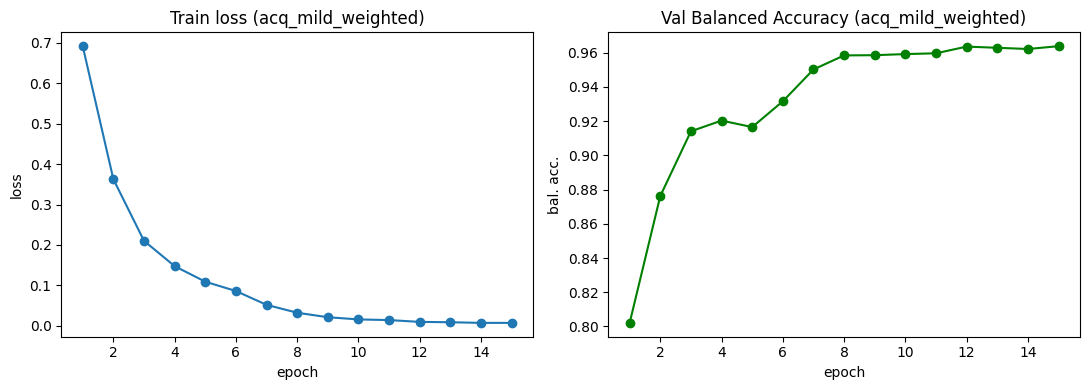

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/curves_acq_mild_weighted.png


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, history['train_loss'], marker='o')
ax[0].set_title(f'Train loss ({TAG})'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('loss')
ax[1].plot(epochs, history['val_balacc'], marker='o', color='green')
ax[1].set_title(f'Val Balanced Accuracy ({TAG})'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('bal. acc.')
plt.tight_layout()
curves_path = RESULTS_DIR / f'curves_{TAG}.png'
plt.savefig(curves_path, dpi=120, bbox_inches='tight')
plt.show()
print('Salvato:', curves_path)

## 8. Valutazione in-distribution ed analisi degli errori

Ricarichiamo il modello migliore e calcoliamo Balanced Accuracy, TPR per classe e
confusion matrix sulla validation. Salviamo tutto in `results/` con il suffisso del livello.

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))
val_balacc, y_true, y_pred = evaluate(model, val_loader)
print(f'[{TAG}] Val Balanced Accuracy: {val_balacc:.4f}')

# TPR (recall) per classe
tpr = recall_score(y_true, y_pred, labels=list(range(NUM_CLASSES)), average=None, zero_division=0)
tpr_df = pd.DataFrame({'class': CLASS_NAMES, 'label': range(NUM_CLASSES), 'tpr_val': tpr})
tpr_csv = RESULTS_DIR / f'per_class_tpr_{TAG}.csv'
tpr_df.to_csv(tpr_csv, index=False)
print('\nTPR per classe (in-distribution):')
print(tpr_df.to_string(index=False))
print('Salvato:', tpr_csv)

[acq_mild_weighted] Val Balanced Accuracy: 0.9638

TPR per classe (in-distribution):
           class  label  tpr_val
         battery      0 0.978836
        clothing      1 0.991781
           glass      2 0.957711
           metal      3 0.954545
         organic      4 0.984772
          papery      5 0.987113
         plastic      6 0.884393
undifferentiated      7 0.971223
Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/per_class_tpr_acq_mild_weighted.csv


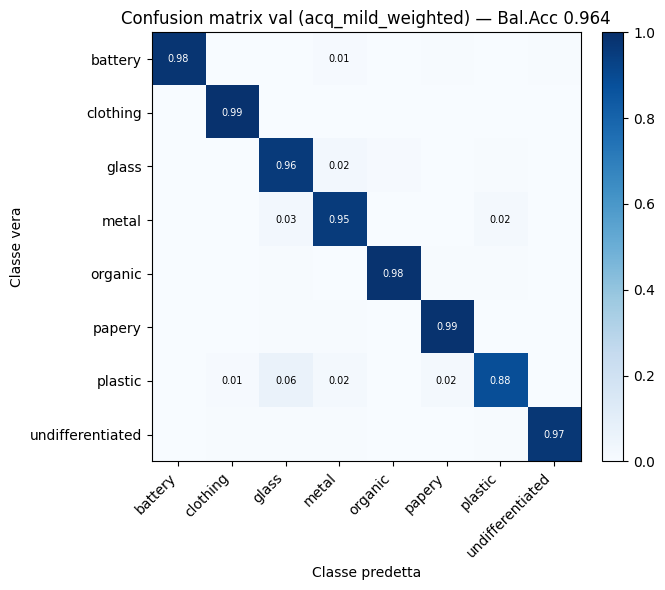

Salvato: /content/drive/MyDrive/2026_MLinf_gr41/Waste-Project/results/confusion_val_acq_mild_weighted.png


In [ ]:
# Confusion matrix normalizzata per riga (sulla classe vera)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Classe predetta'); ax.set_ylabel('Classe vera')
ax.set_title(f'Confusion matrix val ({TAG}) — Bal.Acc {val_balacc:.3f}')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_norm[i, j] >= 0.01:
            ax.text(j, i, f'{cm_norm[i, j]:.2f}', ha='center', va='center',
                    color='white' if cm_norm[i, j] > 0.5 else 'black', fontsize=7)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
cm_path = RESULTS_DIR / f'confusion_val_{TAG}.png'
plt.savefig(cm_path, dpi=120, bbox_inches='tight')
plt.show()
print('Salvato:', cm_path)